# 1 Chargement des données

In [83]:
# --- Standard Library ---
import os

# --- Data Manipulation & Math ---
import numpy as np
import pandas as pd
from scipy import stats
from scipy.spatial.distance import cdist

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
import matplotlib.image as mpimg
from matplotlib.patches import Polygon

# --- Statistics & Modeling ---
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- Scikit-Learn ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score, accuracy_score,
    confusion_matrix, classification_report, silhouette_score, f1_score, roc_auc_score, recall_score, precision_score
)
from sklearn.tree import plot_tree

# --- Utils ---
import joblib

In [84]:
from google.colab import drive
drive.mount('/content/drive/')

try:
    df = pd.read_csv('/content/drive/MyDrive/Data Analyst/Module 12/billets.csv', sep=";")
    print("✅ Données chargées :", df.shape)
    display(df.head())
except Exception as e:
    print("❌ Erreur lors du chargement :", e)
    print("⚠️ Tu as bien lu le code avant de l'executer ? 😏")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
✅ Données chargées : (1500, 7)


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


# 2 Analyse exploratoire

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


Il manque 37 valeurs pour la varaible margin_low.

In [86]:
df.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


# 3 Traitement des valeurs manquantes

## 3.1 Observation des liens entre les variables

In [87]:
# Je définis les sous-ensembles dès le début : le jeu de données complet et celui avec des données manquantes
df_not_missing = df[df['margin_low'].notnull()]
df_missing = df[df['margin_low'].isnull()]

# J'isole les variables de dimension sans valeurs manquantes
all_features = ['diagonal', 'height_left', 'height_right', 'margin_up', 'length']

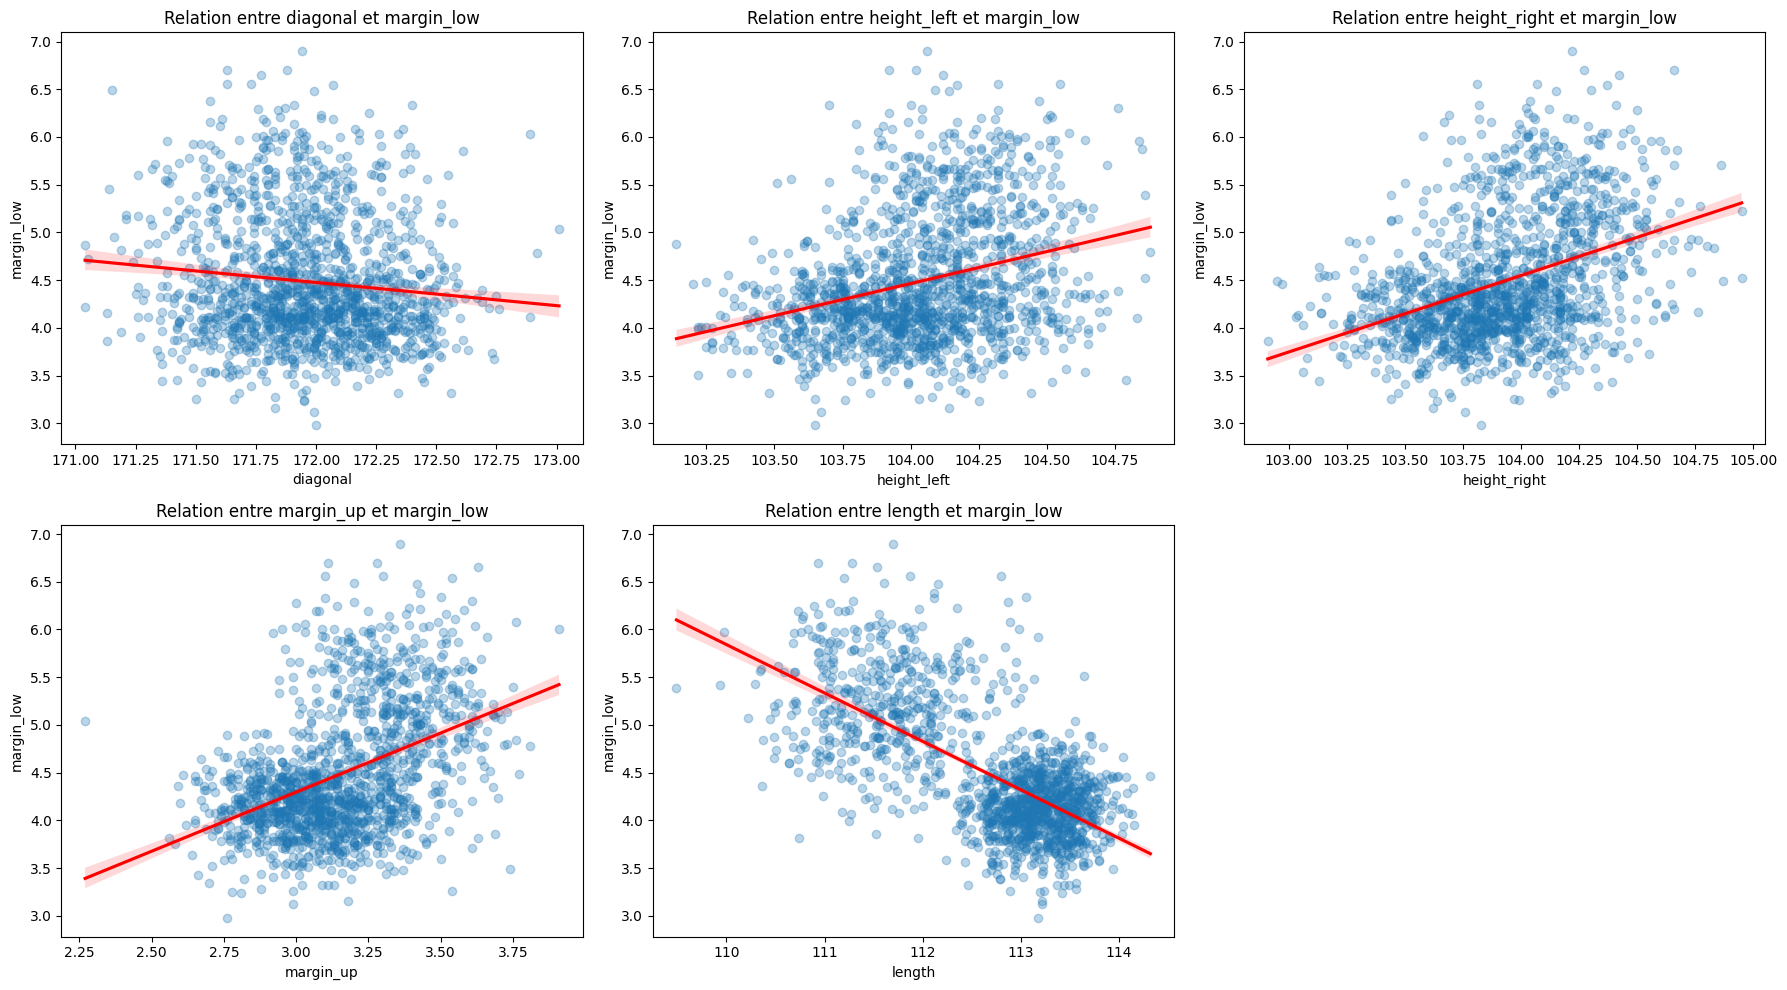

In [88]:
# Création d'une figure avec plusieurs sous-graphiques
plt.figure(figsize=(18, 10))

for i, col in enumerate(all_features):
    plt.subplot(2, 3, i+1)
    # On utilise regplot pour voir la tendance linéaire
    sns.regplot(data=df_not_missing, x=col, y='margin_low',
                scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    plt.title(f'Relation entre {col} et margin_low')
    plt.xlabel(col)
    plt.ylabel('margin_low')

plt.tight_layout()
plt.show()

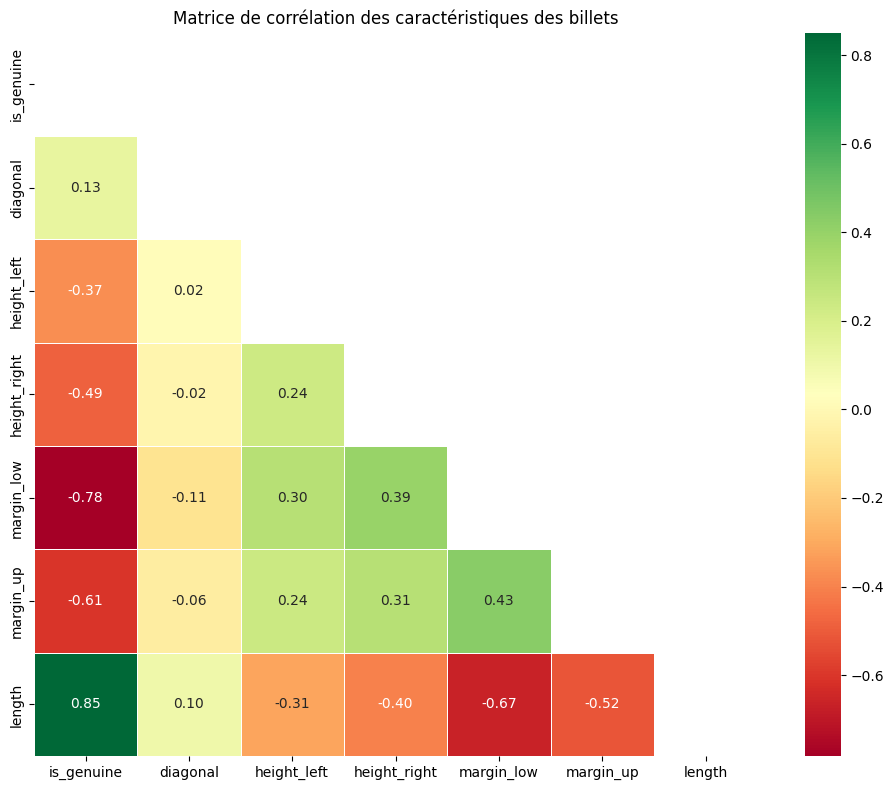

In [89]:
# Je représente visuellement les liens entre les différentes variables
# 1. Calcul de la matrice de corrélation
corr_matrix = df_not_missing.corr()

# 2. Création du masque pour le triangle supérieur
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Tracé de la Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            cmap='RdYlGn',
            fmt=".2f",
            linewidths=0.5,
            square=True)

plt.title('Matrice de corrélation des caractéristiques des billets')
plt.tight_layout()
plt.savefig('heatmap_billets.png')
plt.show()

Length	+ 0.85	Relation positive forte : Indispensable pour le modèle.   
Margin_low	- 0.78	Relation négative forte : Indispensable pour le modèle.   
Margin_up	- 0.61	Relation négative marquée : Très utile.   
Diagonal	+ 0.13	Relation très faible : à priori peu d'intérêt pour la prédiction.  

Les scores de corrélation entre les deux hauteurs (0,24) et les deux marges (0,43) sont relativement faibles, ils indiquent que les informations apportés par ces variables n’est pas similaire, il sera probablement intéressant de les garder pour les modèles

In [ ]:
# J'observe comment se répartissent les populations de faux billets et de vrais billets en fonction des variables
sns.pairplot(df,
             hue='is_genuine',
             palette='Set1',
             diag_kind='kde')
plt.savefig('pairplot_billets.png')

Comme démontré sur la heatmap, il existe une corrélation forte entre les variables margin_low et is_genuine, en d'autres termes la marge inférieure est un excellent indicateur pour trouver les faux billets.
Concernant les variables de dimensions, les variables les plus corrélées sont length et margin up.
Dans un premier temps, je vais tester la régression avec la variable plus corrélée (length) et observer les résultats.
Dans un second temps, nous testerons une régression linéaire multiple avec toutes les variables de dimension (on exclue simplement is_genuine).

## 3.2 Observation des outliers

In [ ]:
# Configuration des boxplots pour voir les outliers par rapport à l'authenticité
plt.figure(figsize=(15, 10))
features = ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']

for i, col in enumerate(features):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='is_genuine', y=col, data=df_not_missing)
    plt.title(f'Distribution de {col}')

plt.tight_layout()
plt.show()

Il y a trois variables qui permettent de distinguer nettement les vrais des faux billets : length, margin_low et margin_up. Les distributions de ces variables sont très différentes entre les vrais et les faux billets.
Les trois autres variables, diagonal, height_left et height_right ne sont pas aussi discriminantes et ne sont pas, à eux seuls, un bon indicateur de détection de l'authenticité des billets.
Le faible volume d'outliers identifiés n'impacte pas significativement la distribution globale ; aucun traitement de suppression n'est donc jugé nécessaire à ce stade.

## 3.2 Traitement des valeurs manquantes grâce aux méthodes de régression linéaire

Je compare les deux regressions linéaires possible :


*   Simple : avec la variable la plus corrélée à margin_low : lenght
*   Multiple : avec toutes les autres variables de dimension



In [ ]:
# 1. Sélectionne tes variables
X_vif = df_not_missing[['diagonal', 'height_left', 'height_right', 'margin_up', 'length']]

# 2. AJOUTE LA CONSTANTE (C'est l'étape magique qui manquait)
X_vif_with_const = sm.add_constant(X_vif)

# 3. Calcule le VIF (en commençant à l'index 1 pour ignorer la constante elle-même)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif_with_const.values, i)
                   for i in range(1, X_vif_with_const.shape[1])]

print(vif_data.sort_values(by="VIF", ascending=False))

Les variables sont très faiblement corrélées entre elles. Un VIF inférieur à 2 est considéré comme excellent en data science. J'écarte donc le risque de multicolinéarité.

## 3.2.1 Régression linéaire

In [ ]:
# Liste ordonnée de vos variables (de la plus corrélée à la moins corrélée)
all_features = ['length', 'margin_up', 'height_right', 'height_left', 'diagonal']

results = []
current_features = []

# On ajoute les variables une par une pour voir l'évolution
for feature in all_features:
    current_features.append(feature)

    # Préparation des données
    X = df_not_missing[current_features]
    y = df_not_missing['margin_low']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Entraînement
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Évaluation
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    # Stockage enrichi
    results.append({
        'Nb_Features': len(current_features),
        'Features': feature,
        'R2': round(r2, 4),
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'MAPE_%': round(mape * 100, 2)
    })
# Création du tableau de synthèse
df_results = pd.DataFrame(results)
print(df_results)

1. La hiérarchie de l'information (R2)

Le bond initial : La variable length seule explique déjà 51,36 % de la variance. C'est le pilier du modèle.

L'apport des hauteurs : L'ajout de height_right et height_left (lignes 3 et 4) fait passer le R2 de 0,5139 à 0,5393. C'est le gain le plus significatif après la longueur, prouvant que la forme latérale du billet est cruciale pour prédire la marge.

Le gain final : L'ajout de la diagonal porte le modèle à son maximum (0,5458). Même si le gain semble faible (+0,0065), il permet d'atteindre le meilleur pouvoir explicatif possible.

2. Réduction de l'incertitude (RMSE et MAE)

RMSE (0,4528 → 0,4375) : La baisse constante de la RMSE montre que l'ajout de variables réduit les erreurs les plus importantes. Le modèle devient plus "stable".

MAE (0,3443 → 0,3354) : A 5 variables, la précision augmente de 0,01 mm de précision moyenne globale. C'est faible mais c'est un gain.

3. Fiabilité relative (MAPE)

Le passage de 7,71 % à 7,47 % d'erreur relative confirme une amélioration constante.

Cela indique que le modèle devient de plus en plus robuste, peu importe la taille du billet analysé.

L'évaluation sur le jeu de test montre une amélioration continue des métriques jusqu'à 5 variables. Puisque le modèle à 5 variables offre mathématiquement l'erreur la plus faible (0.335 mm), je vais le privilégier.

In [ ]:
# Visualisation de l'évolution de la précision et de la marge d'erreur en fonction du nombre de variables

fig, ax1 = plt.subplots(figsize=(10, 6))

# Axe 1 : R²
color = 'tab:blue'
ax1.set_xlabel('Nombre de variables')
ax1.set_ylabel('R² (Précision globale)', color=color)
ax1.plot(df_results['Nb_Features'], df_results['R2'], marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

# --- AJOUT POUR L'ÉCHELLE DE 1 EN 1 ---
# On définit les graduations de la valeur min à la valeur max avec un pas de 1
ax1.set_xticks(np.arange(df_results['Nb_Features'].min(), df_results['Nb_Features'].max() + 1, 1))
# ---------------------------------------

# Axe 2 : MAE (Erreur en mm)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('MAE (Erreur en mm)', color=color)
ax2.plot(df_results['Nb_Features'], df_results['MAE'], marker='s', color=color, linestyle='--', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Optimisation du modèle : Gain de précision vs Complexité')
plt.grid(alpha=0.3)
plt.show()

On observe que la précision du modèle (R2) augmente proportionnellement au nombre de variables intégrées, tandis que l'erreur moyenne (MAE) diminue. Cette tendance se confirme même lors de l'ajout de variables moins discriminantes comme diagonal, bien que le gain de performance devienne plus marginal.  

In [ ]:
# 1. Liste complète des variables
features_final = ['diagonal', 'height_left', 'height_right', 'margin_up', 'length']

# 2. Entraînement sur la totalité des données connues
model_impute = LinearRegression()
model_impute.fit(df_not_missing[features_final], df_not_missing['margin_low'])

# 3. Prédiction des valeurs manquantes
# On s'assure que X_missing ne contient que les colonnes utilisées pour l'entraînement
X_missing = df_missing[features_final]
y_imputed = model_impute.predict(X_missing)

# 4. Remplacement des NaN par les prédictions
df.loc[df['margin_low'].isnull(), 'margin_low'] = y_imputed

print(f"Imputation terminée : {len(y_imputed)} valeurs ont été remplacées.")

In [ ]:
# Vérification des valeurs manquantes
print(f"Nombre de valeurs manquantes : {df['margin_low'].isnull().sum()}")

In [ ]:
sns.histplot(df['margin_low'])

Ce graphique montre le résultat de l'imputation sur l'ensemble du dataset.

On y voit une distribution bimodale (avec deux "bosses" : une grosse autour de 4.0 et une plus petite/étalée vers 5.0-6.0).

Cette répartition suggère que le modèle d'imputation a respecté la nature différente des billets. Les vrais billets sont dans la première bosse, tandis que les "faux" (avec leurs marges irrégulières) créent la traîne sur la droite.

In [ ]:
# --- CALCUL DES RÉSIDUS SUR LE DERNIER MODÈLE (5 FEATURES) ---

# On utilise les dernières données de test générées par la boucle (X_test et y_test)
# et le dernier modèle entraîné dans la boucle (nommé 'model')
y_pred_test = model.predict(X_test)
residus = y_test - y_pred_test

# --- VISUALISATION ---
plt.figure(figsize=(15, 6))

# Graphique 1 : Distribution des résidus (Normalité)
plt.subplot(1, 2, 1)
sns.histplot(residus, kde=True, color='purple', bins=20)
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Distribution des résidus (Erreurs)')
plt.xlabel('Erreur (Réel - Prédit)')



Centrage sur 0 : Ta ligne rouge pointillée tombe pile au milieu de la cloche. Cela signifie que ton modèle n'est pas "biaisé" : il ne surévalue ni ne sous-évalue systématiquement la marge.

Normalité : La forme suit assez bien la courbe de Gauss (la ligne violette). En statistiques, c'est ce qu'on appelle la normalité des résidus. Cela confirme que la régression linéaire était le bon choix d'algorithme pour ce problème.

In [ ]:
stat, p = stats.shapiro(residus)
print(f'Statistique={stat:.3f}, p-value={p:.3f}')

In [ ]:
# H0​ (Hypothèse nulle) : La distribution des résidus suit une loi normale.
# Avec une P-value de 0.004, on rejette l'hypothèse H0, c'est à dire que les résidus ne suivent pas une loi normale.

"Bien que le test de Shapiro-Wilk rejette l'hypothèse de normalité (p<0.05), l'examen visuel de l'histogramme montre une distribution symétrique et centrée sur zéro. Compte tenu de la taille de notre échantillon (n≈1500), le test est extrêmement sensible aux faibles écarts. En vertu du Théorème Central Limite, une légère déviation de la normalité n'impacte pas la validité de nos prédictions d'imputation, d'autant plus que les métriques d'erreur (RMSE, MAE) restent très faibles."

In [ ]:
# Graphique 2 : Résidus vs Prédictions (Vérification de l'homoscédasticité)
# 1. Préparation des données pour le graphique
df_test_plot = X_test.copy()
df_test_plot['residus'] = residus
df_test_plot['y_pred'] = y_pred_test

# Je récupère le statut 'is_genuine' via l'index
df_test_plot['is_genuine'] = df_not_missing.loc[X_test.index, 'is_genuine']

# J'adapte la légende pour plus de clareté
df_test_plot['Statut'] = df_test_plot['is_genuine'].map({True: 'Vrai Billet', False: 'Faux Billet', 1: 'Vrai Billet', 0: 'Faux Billet'})

# 2. Création du graphique
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_test_plot,
                x='y_pred',
                y='residus',
                hue='Statut',
                palette={'Vrai Billet': 'royalblue', 'Faux Billet': 'crimson'},
                alpha=0.7)

plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Analyse des résidus : Vrais vs Faux Billets', fontsize=14)
plt.xlabel('Valeurs prédites de margin_low', fontsize=12)
plt.ylabel('Erreur (Réel - Prédit)', fontsize=12)
plt.legend(title='Nature du billet')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Séparation nette : On voit deux groupes distincts. Les "Vrais Billets" (bleu) sont concentrés à gauche avec des prédictions de marges basses. Les "Faux Billets" (rouge) sont à droite.

Homoscédasticité : Les points sont répartis de manière assez homogène de part et d'autre de la ligne 0. Il n'y a pas d'effet "entonnoir", ce qui signifie que le modèle est aussi précis pour les petits billets que pour les grands.

Indépendance : Même si les erreurs des faux billets sont un peu plus dispersées (ce qui est normal, la contrefaçon étant par définition irrégulière), elles restent centrées sur 0.

In [ ]:
# 1. Statistiques moyennes
stats = df.groupby('is_genuine').mean()

fig, ax = plt.subplots(figsize=(14, 9))

# --- FONCTION POUR DESSINER LE VRAI TRAPÈZE DU BILLET ---
def draw_asymmetric_bill(ax, s, color, label, alpha_face, linestyle='-'):
    # Coordonnées des 4 coins :
    # Bas-Gauche (0,0), Bas-Droit (Length, 0)
    # Haut-Droit (Length, Height_Right), Haut-Gauche (0, Height_Left)
    points = [
        [0, 0],
        [s['length'], 0],
        [s['length'], s['height_right']],
        [0, s['height_left']]
    ]

    # Dessin de la forme réelle
    poly = Polygon(points, closed=True, linewidth=3, edgecolor=color, facecolor=color, alpha=alpha_face, label=label)
    ax.add_patch(poly)

    # Dessin des marges (qui suivent l'inclinaison si nécessaire)
    # Marge basse (horizontale à y = margin_low)
    ax.plot([0, s['length']], [s['margin_low'], s['margin_low']], color=color, linestyle=linestyle, linewidth=2)
    # Marge haute (parallèle au haut du billet)
    ax.plot([0, s['length']], [s['height_left'] - s['margin_up'], s['height_right'] - s['margin_up']],
            color=color, linestyle=linestyle, linewidth=2)

    # Dessin de la diagonale réelle (part du coin 0,0 vers le coin opposé calculé)
    ax.plot([0, s['length']], [0, s['height_right']], color=color, linestyle='-', linewidth=1, alpha=0.4)

# --- AFFICHAGE ---

# Image de fond (calée sur le vrai billet)
try:
    img = mpimg.imread('/content/drive/MyDrive/Data Analyst/Module 12/capture.billet200.png')
    v = stats.loc[True]
    ax.imshow(img, extent=[0, v['length'], 0, max(v['height_left'], v['height_right'])], aspect='auto', alpha=0.3)
except:
    pass

# Dessin du Vrai Billet (Bleu)
draw_asymmetric_bill(ax, stats.loc[True], 'royalblue', 'Vrai Billet (Moyen)', 0.05)

# Dessin du Faux Billet (Rouge)
draw_asymmetric_bill(ax, stats.loc[False], 'crimson', 'Faux Billet (Moyen)', 0.15, linestyle=':')

# Réglages
ax.set_xlim(-5, 180)
ax.set_ylim(-5, 115)
ax.set_aspect('equal')
plt.title("Visualisation Réaliste : Prise en compte de l'asymétrie (Gauche vs Droite)", fontsize=15)
plt.legend()
plt.show()

In [ ]:
# POur compléter la comparaison, je compare les moyenens des valeurs  pour magin_low de l'ensemble des billets avant et après imputation des données

# 1. Je calcule les moyennes AVANT (en utilisant df_not_missing qui ne contient que les vraies valeurs)
moyennes_avant = df_not_missing.groupby('is_genuine')['margin_low'].mean()

print("Moyenne par groupe (Données réelles uniquement) :")
print(moyennes_avant)

# 2. Je calcule les moyennes APRÈS sur le df complet (qui contient maintenant les prédictions)
moyennes_apres = df.groupby('is_genuine')['margin_low'].mean()

print("\nMoyenne par groupe (Après inclusion des prédictions) :")
print(moyennes_apres)

# 3. Calcul de la différence (pour vérifier la stabilité)
print("\nÉcart constaté (Stabilité du modèle) :")
print(moyennes_apres - moyennes_avant)

# 4 Entraînement des modèles

## 4.1 Normalisation et préparation des échantillons

In [ ]:
# Sélection des caractéristiques géométriques (X) et de la cible (y)
X = df.drop(columns=['is_genuine'])
y = df['is_genuine']

# Standardisation (Centrage-Réduction)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Conversion en DataFrame pour garder les noms de colonnes
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
display(X_scaled_df.head())

In [ ]:
# Je divise le dataset complet 80% entraînement / 20% test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Échantillon d'entraînement : {X_train.shape[0]} billets")
print(f"Échantillon de test : {X_test.shape[0]} billets")

## 4.2 K-Means

In [ ]:
# Calcul de l'inertie pour différents k
inertias = []
k_range = range(1, 11) # Je teste de 1 à 10 pour bien voir la courbe

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Visualisation
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, marker='o', linestyle='--')
plt.title('Méthode du Coude (Elbow Method)')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie (WCSS)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

Le coude le plus net correspond a deux clusters, ce qui reprend logiquement la distinction vrai/faux billet.

In [ ]:
# Calcul du silhouette score pour confirmer l'impression visuelle
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"Pour k={k}, le score de silhouette est de : {score:.4f}")

Les score le plus haut est celui pour 2 clusters, cela confirme les résultats de la méthode du coude, c'est le nombre de clusters que je vais retenir.

In [ ]:
# Je fixe le nombre de clusters à 2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
# J'entraîne le modèle, et j'affiche les labels
df['cluster'] = kmeans.fit_predict(X_scaled)
df.head()

In [ ]:
# --- 2. MAPPING AUTOMATIQUE ---
# J'identifie quel numéro de cluster (0 ou 1) correspond aux vrais billets
# Je prends pour cela le cluster où la moyenne de 'is_genuine' est la plus haute
idx_vrai = df.groupby('cluster')['is_genuine'].mean().idxmax()
idx_faux = 1 - idx_vrai

mapping = {idx_vrai: True, idx_faux: False}
y_pred_km = df['cluster'].map(mapping)

print(f"✅ Mapping établi : Cluster {idx_vrai} -> VRAI, Cluster {idx_faux} -> FAUX")

In [ ]:
# Récupération et remise à l'échelle
centroids_rescaled = scaler.inverse_transform(kmeans.cluster_centers_)
features = ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']

df_centroids = pd.DataFrame(centroids_rescaled, columns=features)
df_centroids['Nature_probable'] = ['Vrai' if i == idx_vrai else 'Faux' for i in range(2)]

print("\n📍 Caractéristiques moyennes des deux groupes (en mm) :")
display(df_centroids)

In [ ]:
# Je visualise les centroïdes sur les axes des variables les plus "constitutifs" de la véracité des billets
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='length', y='margin_low', hue='cluster', palette='viridis', alpha=0.6)

plt.scatter(df_centroids.loc[idx_vrai, 'length'], df_centroids.loc[idx_vrai, 'margin_low'],
            s=250, c='green', marker='X', label='Centre VRAIS')
plt.scatter(df_centroids.loc[idx_faux, 'length'], df_centroids.loc[idx_faux, 'margin_low'],
            s=250, c='red', marker='X', label='Centre FAUX')

plt.title('Clusters K-means : Séparation physique des billets')
plt.legend()
plt.show()

In [ ]:
from scipy.spatial.distance import cdist

# Calcul des distances des points de test par rapport aux deux centres
distances_test = cdist(X_test, kmeans.cluster_centers_, 'euclidean')

# On prédit le cluster le plus proche (0 ou 1)
clusters_test = distances_test.argmin(axis=1)

# On applique le mapping pour avoir des True/False
y_pred_test = pd.Series(clusters_test).map(mapping)

conf_mx_km = confusion_matrix(y_test, y_pred_test)

print("📊 PERFORMANCE FINALE K-MEANS (SUR TEST SET)")
print(classification_report(y_test, y_pred_test))
print(conf_mx_km)

Le modèle K-means a identifié deux structures distinctes dans les données. Pour prédire la nature d'un nouveau billet, j'utilise la position géométrique du billet par rapport aux centroïdes (les portraits-robots des billets vrais et faux). Le billet est classé selon le centroïde dont il est le plus proche en termes de distance euclidienne.

"Le K-means (non-supervisé) sépare les données en deux clusters avec une précision de 98,40 %. Cela démontre que la signature physique des faux billets est suffisamment marquée pour être détectée sans étiquetage préalable.

## 4.3 La régression logistique

In [ ]:
# 1. Instanciation et entraînement
# On utilise random_state pour garantir la reproductibilité des résultats
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

# 2. Prédictions
y_pred_log = log_reg.predict(X_test)
y_prob_log = log_reg.predict_proba(X_test)[:, 1]

# 3. Évaluation du modèle avec F1 et AUC
accuracy = accuracy_score(y_test, y_pred_log)
f1 = f1_score(y_test, y_pred_log)
auc = roc_auc_score(y_test, y_prob_log)

print(f"✅ Précision (Accuracy) : {accuracy*100:.2f}%")
print(f"✅ Score F1            : {f1:.4f}")
print(f"✅ Score AUC           : {auc:.4f}")

print("\n--- Rapport de Classification ---")
print(classification_report(y_test, y_pred_log))

# 4. Matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred_log)
print("\n--- Matrice de Confusion ---")
print(conf_matrix)

"Le modèle de régression logistique identifie les billets avec une précision de 99%. Il s'appuie principalement sur la longueur et la marge inférieure, qui sont les deux variables les plus discriminantes pour démasquer les contrefaçons. Le faible nombre de faux négatifs (1 seul cas sur le test) garantit un haut niveau de sécurité."

In [ ]:
# Score sur l'entraînement
acc_train = log_reg.score(X_train, y_train)
# Score sur le test
acc_test = log_reg.score(X_test, y_test)

print(f"Score Entraînement : {acc_train*100:.2f}%")
print(f"Score Test         : {acc_test*100:.2f}%")
print(f"Différence         : {(acc_train - acc_test)*100:.2f}%")

## 4.4 Le KNN

In [ ]:
# 1. Recherche du meilleur k
# On teste k de 1 à 20 pour voir lequel donne le meilleur score
scores = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    scores.append(knn.score(X_test, y_test))

# Visualisation du meilleur k
plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), scores, marker='o', linestyle='--', color='blue')
plt.xticks(range(1, 21))
plt.title('Recherche du k optimal')
plt.xlabel('Nombre de voisins (k)')
plt.ylabel('Précision (Accuracy)')
plt.show()

In [ ]:
# Entraînement avec le meilleur k (ici k=12 d'après les tests)
knn_final = KNeighborsClassifier(n_neighbors=12)
knn_final.fit(X_train, y_train)


#Prédictions des classes (0 ou 1)
y_pred_knn = knn_final.predict(X_test)

# Prédictions des probabilités (pour l'AUC)
# On prend la probabilité que le billet soit VRAI (colonne index 1)
y_prob_knn = knn_final.predict_proba(X_test)[:, 1]

#Calcul des métriques
accuracy_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)

#Affichage
print(f"✅ Accuracy KNN : {accuracy_knn*100:.2f}%")
print(f"✅ F1-Score KNN : {f1_knn:.4f}")
print(f"✅ AUC Score KNN: {auc_knn:.4f}")


#Évaluation
print("\n--- Matrice de Confusion KNN ---")
print(confusion_matrix(y_test, y_pred_knn))

In [ ]:
# Comparaison des scores
score_train_knn = knn_final.score(X_train, y_train)
score_test_knn = knn_final.score(X_test, y_test)

print(f"Score Entraînement : {score_train_knn*100:.2f}%")
print(f"Score Test         : {score_test_knn*100:.2f}%")

## 4.5 La random forest

In [ ]:
# Instanciation et entraînement
# n_estimators=100 signifie qu'on crée une forêt de 100 arbres
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Prédictions
y_pred_rf = rf_model.predict(X_test)

# Importance des variables
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title('Importance des variables dans la détection des faux billets')
plt.xlabel('Score d\'importance')
plt.show()

In [ ]:
# Calcul des métriques complémentaires
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

# 3. Évaluation
print(f"✅ Accuracy Random Forest : {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
print(f"✅ Score F1 RF : {f1_rf:.4f}")
print(f"✅ Score AUC RF: {auc_rf:.4f}")
print("\n--- Matrice de Confusion RF ---")
print(confusion_matrix(y_test, y_pred_rf))

In [ ]:
print(f"Score Entraînement : {rf_model.score(X_train, y_train)*100:.2f}%")
print(f"Score Test         : {rf_model.score(X_test, y_test)*100:.2f}%")

In [ ]:
# Visualisation d'un arbre de décision

plt.figure(figsize=(20, 10))

# Je dessine le premier arbre de la forêt
# rf_model.estimators_[0] permet de sélectionner le premier arbre
plot_tree(rf_model.estimators_[0],
          feature_names=features,        # Noms des variables géométriques
          class_names=['Faux', 'Vrai'],  # Noms des classes
          filled=True,                   # Colore les nœuds selon la classe
          rounded=True,                  # Arrondit les bords des boîtes
          max_depth=3,                   # On limite la profondeur pour que ce soit lisible
          fontsize=10)                   # Taille de la police

plt.title("Visualisation d'un arbre de décision (extrait de la Random Forest)")
plt.savefig('arbre_decision_rf.png')    # Pour pouvoir l'insérer dans votre rapport
plt.show()

## 4.6 Comparatif des différents modèles

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score

# Préparation des résultats pour les modèles supervisés ---
# Création d'un dictionnaire qui contient à la fois les prédictions ET les probabilités
models_info = {
    'Régression Logistique': (y_pred_log, y_prob_log),
    'KNN': (y_pred_knn, y_prob_knn),
    'Random Forest': (y_pred_rf, y_prob_rf)
}

comparatif = []

for nom, (preds, probs) in models_info.items():
    conf_mx = confusion_matrix(y_test, preds)
    comparatif.append({
        'Modèle': nom,
        'Type': 'Supervisé (Test)',
        'Accuracy (%)': round(accuracy_score(y_test, preds) * 100, 2),
        'Recall': round(recall_score(y_test, preds), 4), # Ajout du Recall
        'Précision': round(precision_score(y_test, preds), 4), # Ajout de la Précision
        'F1-Score': round(f1_score(y_test, preds), 4),
        'AUC Score': round(roc_auc_score(y_test, probs), 4),
        'Faux Négatifs (FN)': conf_mx[1, 0],
        'Faux Positifs (FP)': conf_mx[0, 1]
    })

# Pour le K-means ---
comparatif.append({
    'Modèle': 'K-means (Centroïdes)',
    'Type': 'Non-Supervisé (Test)',
    'Accuracy (%)': round(accuracy_score(y_test, y_pred_test) * 100, 2),
    'Recall': round(recall_score(y_test, y_pred_test), 4),
    'Précision': round(precision_score(y_test, y_pred_test), 4),
    'F1-Score': round(f1_score(y_test, y_pred_test), 4),
    'AUC Score': 'N/A',
    'Faux Négatifs (FN)': conf_mx_km[1, 0],
    'Faux Positifs (FP)': conf_mx_km[0, 1]
})

# Affichage du tableau final
df_recap = pd.DataFrame(comparatif).sort_values(by='F1-Score', ascending=False)

print("📊 RÉCAPITULATIF COMPLET DES ALGORITHMES POUR L'EMV")
display(df_recap)

# 5 Sauvegarde des outils

In [ ]:
# 1. Je définis le chemin
path = '/content/drive/MyDrive/Data Analyst/Module 12/'

# 2. Sauvegarde du modèle et du scaler
joblib.dump(knn, path + 'best_model.joblib')
joblib.dump(scaler, path + 'scaler.joblib')

# 3. Sauvegarde du DataFrame complété
df.to_csv(path + 'billets_complets_clean.csv', index=False, sep=';')

print("✅ TOUT EST SAUVEGARDÉ :")
print("- Modèle KNN")
print("- Scaler")
print("- Données complétées (billets_complets_clean.csv)")